# Production CLIP Transfer Training

Single-subject direct flatmap baseline training for cached CLIP image-token embeddings.


## 1. Parameter/Variable/Path Definitions


In [8]:
RUN_SUBJECTS = ["subj01"]
FINAL_EVAL_IMAGES_PER_SUBJECT = 48  # Set to 1000 for the full shared-1000 final eval set.
MODEL_WEIGHTS_TIMESTAMP = "20260907_013858"
SEED = 42


In [9]:
# Modal Volume setup. Data is mounted and read like local files.
import os, re, json, random, time, gc, sys, subprocess, importlib.util, importlib.metadata, math
from collections import defaultdict, OrderedDict

DATA_DIR = "/mnt/braid2-flatmap-data"
print("data dir:", DATA_DIR)
print("data dir exists:", os.path.isdir(DATA_DIR))
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Mount the Modal Volume at {DATA_DIR}.")


def module_available(module_name):
    try:
        return importlib.util.find_spec(module_name) is not None
    except ModuleNotFoundError:
        return False

_missing = []
for module_name, package_name in [
    ("h5py", "h5py"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("scipy", "scipy"),
    ("skimage", "scikit-image"),
    ("torch", "torch"),
    ("torchvision", "torchvision"),
    ("tqdm", "tqdm"),
    ("matplotlib", "matplotlib"),
]:
    if not module_available(module_name):
        _missing.append(package_name)
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_missing])

import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.io import loadmat
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchvision import models

for _required_knob in ["RUN_SUBJECTS", "FINAL_EVAL_IMAGES_PER_SUBJECT", "MODEL_WEIGHTS_TIMESTAMP", "SEED"]:
    if _required_knob not in globals():
        raise RuntimeError(f"Run the key knobs cell first; missing {_required_knob}")

INPUT_DIR = DATA_DIR
FLATMAP_TOKENS_DIR = f"{DATA_DIR}/flatmap_tokens_fp16"
CLIP_TARGETS_DIR = f"{DATA_DIR}/clip_targets_cache"
LOCAL_OUTPUT_ROOT = f"{DATA_DIR}/outputs"
SHARED1000_EVAL_SIZE = 1000
FINAL_EVAL_IMAGES_PER_SUBJECT = min(int(FINAL_EVAL_IMAGES_PER_SUBJECT), SHARED1000_EVAL_SIZE)
if FINAL_EVAL_IMAGES_PER_SUBJECT < 1:
    raise ValueError("FINAL_EVAL_IMAGES_PER_SUBJECT must be at least 1")

def subject_run_tag(subjects):
    return "subj" + "".join(subject[-2:] for subject in subjects)

TRAIN_SUBJECTS = list(RUN_SUBJECTS)
PREDICTION_SUBJECTS = list(RUN_SUBJECTS)
FINAL_EVAL_SUBJECTS = list(RUN_SUBJECTS)
SUBJECT_TO_IDX = {subject: i for i, subject in enumerate(TRAIN_SUBJECTS)}
IDX_TO_SUBJECT = {i: subject for subject, i in SUBJECT_TO_IDX.items()}
NUM_SUBJECTS = len(TRAIN_SUBJECTS)
TRIALS_PER_SESSION = 750
KNOWN_BAD_SESSIONS = {("subj01", 11)}

RUN_TIMESTAMP = MODEL_WEIGHTS_TIMESTAMP or time.strftime("%Y%m%d_%H%M%S")
SPLIT_POLICY = "shared1000_image_id_holdout"
VAL_FRAC = 0.05
ARCH_MODE = "baseline"
OUTPUT_RUN_NAME = f"production_clip_subject01_baseline_{SPLIT_POLICY}_{ARCH_MODE}_{subject_run_tag(RUN_SUBJECTS)}_{RUN_TIMESTAMP}"
OUTPUT_DIR = f"{LOCAL_OUTPUT_ROOT}/{OUTPUT_RUN_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# BrainIT low-level branch settings from paper Appendix D.1/D.2.
VGG_IMAGE_SIZE = 112
VGG_TOKEN_DIM = 512
VGG_LAYER_NAMES = ["relu1_2", "relu2_2", "relu3_3", "relu4_3", "relu5_3"]
VGG_LAYER_TOKEN_COUNTS = [56 * 56, 55 * 55, 28 * 28, 14 * 14, 7 * 7]
VGG_LAYER_OFFSETS = np.cumsum([0] + VGG_LAYER_TOKEN_COUNTS[:-1]).tolist()
VGG_TOTAL_TOKENS = int(sum(VGG_LAYER_TOKEN_COUNTS))
SAMPLE_TOKENS_PER_LAYER = [512, 512, 128, 64, 16]
TEMPERATURE = 0.07

# OpenCLIP ViT-bigG/14 internal image patch tokens, matching bridge_train.py.
CLIP_DIM = 1664
CLIP_NUM_QUERIES = 256
CLIP_LOSS_WEIGHT = 1.0
VGG_LOSS_WEIGHT = 0.25

# Batch sizes and chunk sizes.
BATCH_SIZE = 64                     # VGG+CLIP training batch size
DIP_QUERY_BATCH = 1                    # shared-1000 VGG/CLIP prediction batch size
DIP_BATCH_SIZE = 36                    # DIP inversion batch size
DIP_MIN_BATCH_SIZE = 1                 # minimum DIP batch size after OOM backoff
FINAL_DIFFUSION_BATCH_SIZE = 20        # diffusion candidate batch size, divided by ensemble size
FINAL_EVAL_FEATURE_BATCH_SIZE = 32     # final eval feature-extraction batch size
PREDICT_QUERY_CHUNK = 1024             # VGG token query chunk size during prediction


D_MODEL = 768
N_LAYERS = 4
N_HEADS = 8
FFN_DIM = 3072
DROPOUT = 0.10
EPOCHS = 10
CACHE_TRAIN_SESSIONS_IN_RAM = False
LR = 5e-4
WEIGHT_DECAY = 1e-2
WARMUP_EPOCHS = 15
PLATEAU_PATIENCE = 2
PLATEAU_FACTOR = 0.1
GRAD_CLIP_NORM = 1.0
BRAIN_DIM_OVERRIDE = 768

DIP_INPUT_DIM = 32
DIP_INTERNAL_DIM = 128
DIP_SCALES = 3
DIP_STEPS = 2000
DIP_LR = 1e-2
DIP_INITIAL_NOISE = 0.1
DIP_REG_NOISE = 1.0 / 30.0
DIP_EMA = 0.99
DIP_OUTPUT_SIZE = 112
DIP_UPSAMPLED_SIZE = 256

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass
torch.backends.cudnn.benchmark = True


def ensure_xformers_wheel():
    if any(name == "xformers" or name.startswith("xformers.") for name in sys.modules):
        raise RuntimeError("Restart the kernel/container before repairing xformers; the current process already imported xformers.")

    torch_minor = ".".join(torch.__version__.split("+")[0].split(".")[:2])
    cuda_version = torch.version.cuda
    cuda_tag = f"cu{cuda_version.replace('.', '')}" if cuda_version else None
    target_by_torch_cuda = {
        ("2.8", "12.9"): "0.0.32.post2",
    }
    target = target_by_torch_cuda.get((torch_minor, cuda_version))
    if target is None:
        raise RuntimeError(f"No xformers pin for torch {torch.__version__} / CUDA {cuda_version}; do not install xformers blindly.")

    try:
        installed = importlib.metadata.version("xformers")
    except importlib.metadata.PackageNotFoundError:
        installed = None

    if installed != target:
        print(f"installing xformers=={target} for torch {torch.__version__} / CUDA {cuda_version} (was {installed})")
        subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "xformers"])
        cmd = [
            sys.executable, "-m", "pip", "install",
            "--no-cache-dir", "--force-reinstall", "--no-deps",
            f"xformers=={target}",
        ]
        if cuda_tag:
            cmd += ["--index-url", f"https://download.pytorch.org/whl/{cuda_tag}"]
        subprocess.check_call(cmd)
    else:
        print(f"xformers=={target} already matches torch {torch.__version__} / CUDA {cuda_version}")

    subprocess.check_call([
        sys.executable, "-c",
        "import torch, xformers, xformers.ops; "
        "print({'torch': torch.__version__, 'cuda': torch.version.cuda, 'xformers': xformers.__version__})",
    ])


ensure_xformers_wheel()


def torch_load_cpu(path, *args, **kwargs):
    kwargs.setdefault("map_location", "cpu")
    try:
        kwargs.setdefault("weights_only", False)
        return torch.load(path, *args, **kwargs)
    except TypeError:
        kwargs.pop("weights_only", None)
        return torch.load(path, *args, **kwargs)


def require_file(path):
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    return path

print(f"device={DEVICE} batch_size={BATCH_SIZE} output={OUTPUT_DIR}")
print(f"subjects={TRAIN_SUBJECTS}")
print(f"final_eval_images_per_subject={FINAL_EVAL_IMAGES_PER_SUBJECT} / {SHARED1000_EVAL_SIZE}")
print(f"model_weights_timestamp={MODEL_WEIGHTS_TIMESTAMP or '<new run>'}")
print(f"VGG tokens={VGG_TOTAL_TOKENS} layer_counts={VGG_LAYER_TOKEN_COUNTS}")


data dir: /mnt/braid2-flatmap-data
data dir exists: True
xformers==0.0.32.post2 already matches torch 2.8.0+cu129 / CUDA 12.9
{'torch': '2.8.0+cu129', 'cuda': '12.9', 'xformers': '0.0.32.post2'}
device=cuda batch_size=64 output=/mnt/braid2-flatmap-data/outputs/production_clip_subject01_baseline_shared1000_image_id_holdout_baseline_subj01_20260907_013858
subjects=['subj01']
final_eval_images_per_subject=48 / 1000
model_weights_timestamp=20260907_013858
VGG tokens=7190 layer_counts=[3136, 3025, 784, 196, 49]


## 2. Setup Code/All Data Loading


In [10]:
EXP = require_file(f"{INPUT_DIR}/nsd_expdesign.mat")
mat = loadmat(EXP)

masterordering = mat["masterordering"].reshape(-1).astype(np.int64) - 1
subjectim = mat["subjectim"].astype(np.int64) - 1
shared_ids = set(mat["sharedix"].reshape(-1).astype(np.int64) - 1)

imgbrick_ids_by_subject = {}
for subject in TRAIN_SUBJECTS:
    subject_idx = int(subject[-2:]) - 1
    imgbrick_ids_by_subject[subject] = subjectim[subject_idx, masterordering]


def flatmap_candidates(subject, sess):
    return [
        f"{FLATMAP_TOKENS_DIR}/{subject}_session{sess:02d}_fp16.pt",
        f"{FLATMAP_TOKENS_DIR}/{subject}_flatmap_tokens_session{sess:02d}.pt",
    ]


def flatmap_read_path(subject, sess):
    for path in flatmap_candidates(subject, sess):
        if os.path.isfile(path):
            return path
    raise FileNotFoundError(f"Missing flatmap session {subject} {sess:02d}. Checked: {flatmap_candidates(subject, sess)}")


def discover_sessions(subject):
    if not os.path.isdir(FLATMAP_TOKENS_DIR):
        raise FileNotFoundError(FLATMAP_TOKENS_DIR)
    nums = []
    for name in os.listdir(FLATMAP_TOKENS_DIR):
        if not name.startswith(subject):
            continue
        match = re.search(r"session(\d+)", name)
        if match:
            nums.append(int(match.group(1)))
    nums = sorted(set(s for s in nums if (subject, s) not in KNOWN_BAD_SESSIONS))
    if len(nums) < 2:
        raise RuntimeError(f"{subject} needs at least 2 usable sessions, found {nums}")
    return nums


session_nums_by_subject = {subject: discover_sessions(subject) for subject in TRAIN_SUBJECTS}
train_pairs = []
val_pairs = []
for subject in TRAIN_SUBJECTS:
    sessions = session_nums_by_subject[subject]
    train_pairs.extend((subject, sess) for sess in sessions)
    val_pairs.extend((subject, sess) for sess in sessions)
    print(f"{subject}: {len(sessions)} sessions train={sessions} val={sessions}")
print(f"total: {len(train_pairs)} train sessions, {len(val_pairs)} val sessions")


def load_flatmap_tokens(subject, sess):
    brain_tokens = torch_load_cpu(flatmap_read_path(subject, sess))
    if brain_tokens.dtype != torch.float16:
        brain_tokens = brain_tokens.half()
    if not torch.isfinite(brain_tokens).all():
        bad = int((~torch.isfinite(brain_tokens)).sum().item())
        raise ValueError(f"{subject} session {sess:02d} has {bad} non-finite flatmap token values")
    return brain_tokens.contiguous()


def ids_for_session(subject, sess, n_rows):
    start = (sess - 1) * TRIALS_PER_SESSION
    return imgbrick_ids_by_subject[subject][start:start + n_rows].astype(np.int64)


FINAL_HELDOUT_IMG_IDS = set(int(i) for i in shared_ids)
VAL_HELDOUT_IMG_IDS_BY_SUBJECT = {}
for subject in TRAIN_SUBJECTS:
    nonshared_img_ids = np.array(sorted({
        int(img_id)
        for sess in session_nums_by_subject[subject]
        for img_id in ids_for_session(subject, sess, TRIALS_PER_SESSION)
        if int(img_id) not in FINAL_HELDOUT_IMG_IDS
    }), dtype=np.int64)
    image_perm = np.random.RandomState(SEED + SUBJECT_TO_IDX[subject]).permutation(nonshared_img_ids)
    n_val_images = int(VAL_FRAC * len(image_perm))
    VAL_HELDOUT_IMG_IDS_BY_SUBJECT[subject] = set(map(int, image_perm[:n_val_images]))
VAL_HELDOUT_IMG_IDS_ALL = set().union(*VAL_HELDOUT_IMG_IDS_BY_SUBJECT.values())
TRAIN_BLOCKED_IMG_IDS_BY_SUBJECT = {
    subject: FINAL_HELDOUT_IMG_IDS | VAL_HELDOUT_IMG_IDS_ALL
    for subject in TRAIN_SUBJECTS
}


def split_keep_mask(subject, img_ids, split):
    ids = [int(i) for i in img_ids.tolist()]
    if split == "train":
        blocked = TRAIN_BLOCKED_IMG_IDS_BY_SUBJECT[subject]
        keep = [img_id not in blocked for img_id in ids]
    elif split == "val":
        heldout = VAL_HELDOUT_IMG_IDS_BY_SUBJECT[subject]
        keep = [img_id in heldout for img_id in ids]
    elif split in {"all", "eval"}:
        keep = [True] * len(ids)
    else:
        raise ValueError(f"unknown split={split!r}")
    return torch.as_tensor(keep, dtype=torch.bool)


def apply_split_filter(subject, brain_tokens, img_ids, split):
    keep = split_keep_mask(subject, img_ids, split)
    return brain_tokens[keep], img_ids[keep]


def assert_clean_image_id_splits():
    for subject in TRAIN_SUBJECTS:
        train_seen = set()
        for train_subject, sess in train_pairs:
            if train_subject != subject:
                continue
            ids = torch.from_numpy(ids_for_session(subject, sess, TRIALS_PER_SESSION)).long()
            keep = split_keep_mask(subject, ids, "train")
            train_seen.update(int(i) for i in ids[keep].tolist())
        val_seen = set()
        for val_subject, sess in val_pairs:
            if val_subject != subject:
                continue
            ids = torch.from_numpy(ids_for_session(subject, sess, TRIALS_PER_SESSION)).long()
            keep = split_keep_mask(subject, ids, "val")
            val_seen.update(int(i) for i in ids[keep].tolist())
        assert train_seen.isdisjoint(FINAL_HELDOUT_IMG_IDS), f"{subject}: train/final image-id overlap"
        assert train_seen.isdisjoint(VAL_HELDOUT_IMG_IDS_ALL), f"{subject}: train/global-val image-id overlap"
        assert val_seen.isdisjoint(FINAL_HELDOUT_IMG_IDS), f"{subject}: val/final image-id overlap"
        assert train_seen.isdisjoint(val_seen), f"{subject}: train/val image-id overlap"
        print(
            f"{subject}: clean image-id split train_unique={len(train_seen)} "
            f"val_unique={len(val_seen)} final_heldout={len(FINAL_HELDOUT_IMG_IDS)}"
        )


assert_clean_image_id_splits()


def infer_flatmap_shape():
    subject, sess = train_pairs[0]
    sample = load_flatmap_tokens(subject, sess)
    if sample.ndim != 3:
        raise ValueError(f"expected flatmap tokens [trials, patches, dim], got {tuple(sample.shape)}")
    return int(sample.shape[1]), int(sample.shape[2])


NUM_FLATMAP_PATCHES, FLATMAP_TOKEN_DIM = infer_flatmap_shape()
print(f"flatmap direct tokens: patches={NUM_FLATMAP_PATCHES} dim={FLATMAP_TOKEN_DIM}")


subj01: 39 sessions train=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40] val=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
total: 39 train sessions, 39 val sessions
subj01: clean image-id split train_unique=8528 val_unique=448 final_heldout=1000
flatmap direct tokens: patches=1456 dim=768


## 3. Define Full Model Architecture


In [11]:

class CrossAttentionBridge(nn.Module):
    def __init__(self, brain_dim, target_dim, num_queries, d_model, n_layers, n_heads, ffn_dim, dropout):
        super().__init__()
        self.query_embed = nn.Parameter(torch.randn(num_queries, d_model) * 0.02)
        self.brain_proj = nn.Linear(brain_dim, d_model) if brain_dim != d_model else nn.Identity()
        self.brain_norm = nn.LayerNorm(d_model)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, target_dim)

    def forward(self, brain_tokens, query_indices=None):
        b = brain_tokens.shape[0]
        memory = self.brain_norm(self.brain_proj(brain_tokens))
        if query_indices is None:
            queries = self.query_embed.unsqueeze(0).expand(b, -1, -1)
        elif query_indices.ndim == 1:
            queries = self.query_embed[query_indices].unsqueeze(0).expand(b, -1, -1)
        else:
            queries = self.query_embed[query_indices]
        out = self.decoder(tgt=queries, memory=memory)
        return self.output_proj(out)


class FlatmapSingleHeadBridge(nn.Module):
    def __init__(self, brain_dim, target):
        super().__init__()
        if target not in {"vgg", "clip"}:
            raise ValueError(f"target must be 'vgg' or 'clip', got {target!r}")
        self.target = target
        self.num_patches = int(NUM_FLATMAP_PATCHES)
        if target == "vgg":
            target_dim = VGG_TOKEN_DIM
            num_queries = VGG_TOTAL_TOKENS
        else:
            target_dim = CLIP_DIM
            num_queries = CLIP_NUM_QUERIES
        self.bridge = CrossAttentionBridge(
            brain_dim=brain_dim,
            target_dim=target_dim,
            num_queries=num_queries,
            d_model=D_MODEL,
            n_layers=N_LAYERS,
            n_heads=N_HEADS,
            ffn_dim=FFN_DIM,
            dropout=DROPOUT,
        )

    def forward(self, brain_tokens, query_indices=None):
        return self.bridge(brain_tokens, query_indices=query_indices)


model = None
brain_dim = int(FLATMAP_TOKEN_DIM)


def initialize_fresh_model(target, label=None):
    global model, brain_dim
    if target not in {"vgg", "clip"}:
        raise ValueError(f"target must be 'vgg' or 'clip', got {target!r}")
    brain_dim = int(FLATMAP_TOKEN_DIM)
    model = FlatmapSingleHeadBridge(brain_dim, target=target).to(DEVICE)
    params_m = sum(p.numel() for p in model.parameters()) / 1e6
    label = label or target
    if target == "vgg":
        target_desc = f"VGG [{VGG_TOTAL_TOKENS}, {VGG_TOKEN_DIM}]"
    else:
        target_desc = f"CLIP [{CLIP_NUM_QUERIES}, {CLIP_DIM}]"
    print(f"initialized {label}: brain_dim={brain_dim} target={target_desc} params={params_m:.1f}M")
    print(f"single-subject direct flatmap baseline architecture: {NUM_FLATMAP_PATCHES} patches -> transformer memory tokens")
    return model


## 4. Train CLIP Token Predictor


In [12]:
# Shared training helpers. VGG and CLIP train as separate single-head models from fresh initialization.

def sample_layer_indices(train=True):
    query_ids, splits = [], []
    for offset, n_tokens, k in zip(VGG_LAYER_OFFSETS, VGG_LAYER_TOKEN_COUNTS, SAMPLE_TOKENS_PER_LAYER):
        k = min(k, n_tokens)
        if train:
            ids = torch.randperm(n_tokens, device=DEVICE)[:k]
        else:
            ids = torch.linspace(0, n_tokens - 1, steps=k, device=DEVICE).long()
        query_ids.append(ids + offset)
        splits.append(k)
    return torch.cat(query_ids), splits


def select_target_tokens(tokens_by_layer, query_ids, splits):
    chunks = []
    start = 0
    for li, (offset, k) in enumerate(zip(VGG_LAYER_OFFSETS, splits)):
        local_ids = query_ids[start:start + k] - offset
        chunks.append(tokens_by_layer[li][:, local_ids])
        start += k
    return torch.cat(chunks, dim=1)


def info_nce_by_position(pred, target):
    b, k, _ = pred.shape
    if b < 2:
        return F.mse_loss(pred, target)
    pred = F.normalize(pred.float(), dim=-1)
    target = F.normalize(target.float(), dim=-1)
    logits = torch.einsum("bkd,ckd->kbc", pred, target) / TEMPERATURE
    labels = torch.arange(b, device=pred.device).repeat(k)
    loss_i = F.cross_entropy(logits.reshape(k * b, b), labels)
    loss_t = F.cross_entropy(logits.transpose(1, 2).reshape(k * b, b), labels)
    return 0.5 * (loss_i + loss_t)


def split_layers(x, splits):
    out, start = [], 0
    for k in splits:
        out.append(x[:, start:start + k])
        start += k
    return out


def vgg_contrastive_loss(pred, target, splits):
    loss = pred.new_tensor(0.0)
    parts = {}
    for name, p, t in zip(VGG_LAYER_NAMES, split_layers(pred, splits), split_layers(target, splits)):
        layer_loss = info_nce_by_position(p, t)
        parts[f"nce_{name}"] = layer_loss
        loss = loss + layer_loss
    return loss / len(splits), parts


def feature_metrics(pred, target):
    return {
        "mse": float(F.mse_loss(pred.float(), target.float()).detach().cpu()),
        "cos": float(F.cosine_similarity(pred.float().flatten(1), target.float().flatten(1), dim=1).mean().detach().cpu()),
    }


clip_targets_by_subject = {}


def get_clip_targets(subject):
    if subject not in clip_targets_by_subject:
        path = require_file(f"{CLIP_TARGETS_DIR}/{subject}_clip_targets.pt")
        clip_targets_by_subject[subject] = torch_load_cpu(path)
        print(f"loaded CLIP targets {subject}: {len(clip_targets_by_subject[subject])} images")
    return clip_targets_by_subject[subject]


def clip_targets_for_ids(subject, img_ids):
    clip_by_imgbrick = get_clip_targets(subject)
    targets = torch.stack([clip_by_imgbrick[int(img_id)] for img_id in img_ids]).contiguous()
    expected = (CLIP_NUM_QUERIES, CLIP_DIM)
    if tuple(targets.shape[1:]) != expected:
        raise ValueError(f"expected CLIP targets [B, {expected[0]}, {expected[1]}], got {tuple(targets.shape)}")
    if not torch.isfinite(targets).all():
        bad = int((~torch.isfinite(targets)).sum().item())
        raise ValueError(f"CLIP target batch has {bad} non-finite values")
    return targets


session_cache = {}
bad_pairs = set()


def load_session(subject, sess, split="train"):
    key = (subject, int(sess), split)
    if CACHE_TRAIN_SESSIONS_IN_RAM and key in session_cache:
        return session_cache[key]
    bad_key = (subject, int(sess))
    if bad_key in bad_pairs:
        return None
    try:
        brain_tokens = load_flatmap_tokens(subject, sess)
        ids = torch.from_numpy(ids_for_session(subject, sess, brain_tokens.shape[0])).long()
        brain_tokens, ids = apply_split_filter(subject, brain_tokens, ids, split)
        if brain_tokens.shape[0] == 0:
            return None
        loaded = (brain_tokens, ids)
        if CACHE_TRAIN_SESSIONS_IN_RAM:
            session_cache[key] = loaded
        return loaded
    except Exception as exc:
        print(f"[bad session] {subject} session {sess:02d}: {exc}; skipping")
        bad_pairs.add(bad_key)
        return None


def assert_checkpoint_split_policy(ckpt, path):
    if not isinstance(ckpt, dict):
        raise ValueError(f"refusing to load legacy bare checkpoint without split metadata: {path}")
    if ckpt.get("split_policy") != SPLIT_POLICY:
        raise ValueError(
            f"refusing to load checkpoint with split_policy={ckpt.get('split_policy')!r}; "
            f"expected {SPLIT_POLICY!r}: {path}"
        )
    if float(ckpt.get("val_frac", VAL_FRAC)) != float(VAL_FRAC):
        raise ValueError(
            f"refusing to load checkpoint with val_frac={ckpt.get('val_frac')!r}; "
            f"expected {VAL_FRAC!r}: {path}"
        )

    expected_arch_token = "direct_flatmap"
    arch = str(ckpt.get("architecture", ""))
    if expected_arch_token not in arch:
        raise ValueError(
            f"refusing to load checkpoint with architecture={arch!r}; "
            f"expected architecture containing {expected_arch_token!r}: {path}"
        )


In [13]:
# Domain-specific training helper functions.
# Run this once before the VGG and CLIP training cells.
def optimizer_lr(opt):
    return float(opt.param_groups[0]["lr"])


def set_domain_epoch_lr(opt, base_lr, epoch):
    if WARMUP_EPOCHS <= 0 or epoch > WARMUP_EPOCHS:
        return
    scale = max(epoch, 1) / WARMUP_EPOCHS
    for group in opt.param_groups:
        group["lr"] = base_lr * scale


def reset_all_trainable():
    for p in model.parameters():
        p.requires_grad_(True)


def domain_trainable_params(domain):
    if domain not in {"vgg", "clip"}:
        raise ValueError(f"unknown domain={domain!r}")
    if getattr(model, "target", None) != domain:
        raise ValueError(f"active model target={getattr(model, 'target', None)!r}; expected {domain!r}")
    reset_all_trainable()
    params = [p for p in model.parameters() if p.requires_grad]
    print(f"{domain} single-head training params: {sum(p.numel() for p in params) / 1e6:.1f}M")
    return params


def load_model_state(path):
    ckpt = torch_load_cpu(path, map_location=DEVICE)
    assert_checkpoint_split_policy(ckpt, path)
    if isinstance(ckpt, dict) and ckpt.get("domain") != getattr(model, "target", None):
        raise ValueError(f"checkpoint domain={ckpt.get('domain')!r} does not match active model target={getattr(model, 'target', None)!r}: {path}")
    model.load_state_dict(ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt)
    return ckpt


def domain_checkpoint_payload(domain, epoch, best_val, opt, scheduler, target_epochs):
    return {
        "model": model.state_dict(),
        "optimizer": opt.state_dict(),
        "scheduler": scheduler.state_dict(),
        "epoch": int(epoch),
        "best_val": float(best_val),
        "domain": domain,
        "source_checkpoint": None,
        "initialization": "scratch",
        "architecture": "domain_specialized_" + domain + "_single_head_from_scratch_subject01_baseline_direct_flatmap",
        "subjects": TRAIN_SUBJECTS,
        "num_flatmap_patches": NUM_FLATMAP_PATCHES,
        "architecture_mode": ARCH_MODE,
        "d_model": D_MODEL,
        "n_layers": N_LAYERS,
        "train_epochs": int(target_epochs),
        "train_lr": DOMAIN_TRAIN_LR,
        "split_policy": SPLIT_POLICY,
        "val_frac": VAL_FRAC,
        "final_heldout_image_ids_count": len(FINAL_HELDOUT_IMG_IDS),
        "val_heldout_image_ids_by_subject_count": {subject: len(ids) for subject, ids in VAL_HELDOUT_IMG_IDS_BY_SUBJECT.items()},
        "val_heldout_image_ids_all_count": len(VAL_HELDOUT_IMG_IDS_ALL),
    }


def load_domain_start(domain, latest_path, history_path, opt, scheduler):
    history = []
    best_val = float("inf")
    start_epoch = 1
    if os.path.exists(history_path):
        with open(history_path) as f:
            history = json.load(f)
        if history:
            best_val = min(h["val_loss"] for h in history)
            start_epoch = max(h["epoch"] for h in history) + 1
    if os.path.exists(latest_path):
        ckpt = load_model_state(latest_path)
        if isinstance(ckpt, dict) and "optimizer" in ckpt:
            opt.load_state_dict(ckpt["optimizer"])
        if isinstance(ckpt, dict) and "scheduler" in ckpt:
            scheduler.load_state_dict(ckpt["scheduler"])
        if isinstance(ckpt, dict) and "epoch" in ckpt:
            start_epoch = max(start_epoch, int(ckpt["epoch"]) + 1)
        if isinstance(ckpt, dict) and "best_val" in ckpt:
            best_val = min(best_val, float(ckpt["best_val"]))
        print(f"resuming {domain} training from {latest_path}; next epoch={start_epoch}")
    else:
        print(f"starting {domain} training from fresh random initialization")
    return history, best_val, start_epoch


def save_domain_progress(domain, epoch, best_val, history, opt, scheduler, latest_path, best_path, history_path, history_csv_path, target_epochs, is_best=False):
    payload = domain_checkpoint_payload(domain, epoch, best_val, opt, scheduler, target_epochs)
    torch.save(payload, latest_path)
    if is_best:
        torch.save(payload, best_path)
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)
    if history:
        pd.DataFrame(history).to_csv(history_csv_path, index=False)

def expected_batches_for_pairs(pairs, split):
    total = 0
    for subject, sess in pairs:
        ids = torch.from_numpy(ids_for_session(subject, sess, TRIALS_PER_SESSION)).long()
        keep = split_keep_mask(subject, ids, split)
        n_rows = int(keep.sum().item())
        if n_rows:
            total += math.ceil(n_rows / BATCH_SIZE)
    return total


def run_clip_train_epoch(pairs, epoch, train=True):
    model.train(train)
    totals = defaultdict(float)
    n_batches = 0
    order = list(pairs)
    split = "train" if train else "val"
    if train:
        random.shuffle(order)
        set_domain_epoch_lr(clip_train_optimizer, DOMAIN_TRAIN_LR, epoch)
    desc = f"[train clip] epoch {epoch}/{CLIP_TRAIN_EPOCHS} ({split})"
    total_batches = expected_batches_for_pairs(order, split)
    progress = tqdm(total=total_batches, desc=desc, leave=False, unit="batch")
    try:
        for subject, sess in order:
            loaded = load_session(subject, sess, split=split)
            if loaded is None:
                continue
            brain_tokens, img_ids = loaded
            perm = torch.randperm(brain_tokens.shape[0]) if train else torch.arange(brain_tokens.shape[0])
            for b0 in range(0, len(perm), BATCH_SIZE):
                idx = perm[b0:b0 + BATCH_SIZE]
                brain_batch = brain_tokens[idx].to(DEVICE, non_blocking=True).float()
                id_batch = img_ids[idx]
                clip_target = clip_targets_for_ids(subject, id_batch).to(DEVICE, non_blocking=True).float()

                with torch.set_grad_enabled(train):
                    with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                        pred = model(brain_batch)
                        loss = F.mse_loss(pred.float(), clip_target)

                if train:
                    clip_train_optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_((p for p in model.parameters() if p.requires_grad), GRAD_CLIP_NORM)
                    clip_train_optimizer.step()

                metrics = feature_metrics(pred, clip_target)
                totals["loss"] += float(loss.detach().cpu())
                totals["mse"] += metrics["mse"]
                totals["cos"] += metrics["cos"]
                totals["lr"] += optimizer_lr(clip_train_optimizer)
                n_batches += 1
                progress.update(1)
                progress.set_postfix(subject=subject, sess=int(sess), loss=f"{float(loss.detach().cpu()):.4f}")
            if not CACHE_TRAIN_SESSIONS_IN_RAM:
                del brain_tokens, img_ids
                gc.collect()
    finally:
        progress.close()
    if n_batches == 0:
        raise RuntimeError(f"no valid batches for CLIP training epoch; bad_pairs={sorted(bad_pairs)}")
    return {k: v / n_batches for k, v in totals.items()}


def _first_debug_batch(pairs, split="train", batch_size=None):
    batch_size = int(batch_size or min(BATCH_SIZE, 64))
    for subject, sess in pairs:
        loaded = load_session(subject, sess, split=split)
        if loaded is None:
            continue
        brain_tokens, img_ids = loaded
        if brain_tokens.shape[0] < 2:
            continue
        n = min(batch_size, brain_tokens.shape[0])
        return subject, int(sess), brain_tokens[:n], img_ids[:n]
    raise RuntimeError(f"no usable debug batch for split={split!r}")


In [18]:
# Set this to the total CLIP training epoch you want this cell to reach.
# Example: leave at 10 to skip after epoch 10; change to 20 to train epochs 11-20.
CLIP_TRAIN_EPOCHS = 25

# Domain-specific training: CLIP head from scratch.
# Resumes from clip_latest.pt when present; otherwise starts from fresh random initialization.
# Optional: set this to an existing run timestamp here so you can start rerunning at this cell.
TRAIN_MODEL_WEIGHTS_TIMESTAMP = globals().get("MODEL_WEIGHTS_TIMESTAMP", "")
if TRAIN_MODEL_WEIGHTS_TIMESTAMP:
    RUN_TIMESTAMP = TRAIN_MODEL_WEIGHTS_TIMESTAMP
    OUTPUT_RUN_NAME = f"production_clip_subject01_baseline_{SPLIT_POLICY}_{ARCH_MODE}_{subject_run_tag(RUN_SUBJECTS)}_{RUN_TIMESTAMP}"
    OUTPUT_DIR = f"{LOCAL_OUTPUT_ROOT}/{OUTPUT_RUN_NAME}"

DOMAIN_TRAIN_LR = LR

BEST_VGG_CKPT_PATH = f"{OUTPUT_DIR}/vgg_best.pt"
LATEST_VGG_CKPT_PATH = f"{OUTPUT_DIR}/vgg_latest.pt"
BEST_CLIP_CKPT_PATH = f"{OUTPUT_DIR}/clip_best.pt"
LATEST_CLIP_CKPT_PATH = f"{OUTPUT_DIR}/clip_latest.pt"
VGG_TRAIN_HISTORY_PATH = f"{OUTPUT_DIR}/train_vgg_history.json"
VGG_TRAIN_HISTORY_CSV_PATH = f"{OUTPUT_DIR}/train_vgg_history.csv"
CLIP_TRAIN_HISTORY_PATH = f"{OUTPUT_DIR}/train_clip_history.json"
CLIP_TRAIN_HISTORY_CSV_PATH = f"{OUTPUT_DIR}/train_clip_history.csv"

initialize_fresh_model("clip", "clip scratch")

clip_train_optimizer = torch.optim.AdamW(domain_trainable_params("clip"), lr=DOMAIN_TRAIN_LR, weight_decay=WEIGHT_DECAY)
clip_train_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    clip_train_optimizer,
    mode="min",
    factor=PLATEAU_FACTOR,
    patience=PLATEAU_PATIENCE,
)
clip_train_history, best_clip_val, clip_train_start_epoch = load_domain_start(
    "clip",
    LATEST_CLIP_CKPT_PATH,
    CLIP_TRAIN_HISTORY_PATH,
    clip_train_optimizer,
    clip_train_scheduler,
)

if clip_train_start_epoch > CLIP_TRAIN_EPOCHS:
    print(f"CLIP training already complete for CLIP_TRAIN_EPOCHS={CLIP_TRAIN_EPOCHS}; loaded {len(clip_train_history)} rows")
else:
    for epoch in range(clip_train_start_epoch, CLIP_TRAIN_EPOCHS + 1):
        train_scores = run_clip_train_epoch(train_pairs, epoch, train=True)
        val_scores = run_clip_train_epoch(val_pairs, epoch, train=False)
        row = {"epoch": epoch, **{f"train_{k}": v for k, v in train_scores.items()}, **{f"val_{k}": v for k, v in val_scores.items()}}
        clip_train_history.append(row)
        improved = row["val_loss"] < best_clip_val
        if improved:
            best_clip_val = row["val_loss"]
        if epoch > WARMUP_EPOCHS:
            clip_train_scheduler.step(row["val_loss"])
        save_domain_progress(
            "clip",
            epoch,
            best_clip_val,
            clip_train_history,
            clip_train_optimizer,
            clip_train_scheduler,
            LATEST_CLIP_CKPT_PATH,
            BEST_CLIP_CKPT_PATH,
            CLIP_TRAIN_HISTORY_PATH,
            CLIP_TRAIN_HISTORY_CSV_PATH,
            CLIP_TRAIN_EPOCHS,
            is_best=improved,
        )
        print(
            f"CLIP training epoch {epoch:02d} lr={optimizer_lr(clip_train_optimizer):.2e} "
            f"train_loss={row['train_loss']:.4f} train_cos={row['train_cos']:.4f} "
            f"val_loss={row['val_loss']:.4f} val_cos={row['val_cos']:.4f} best_val={best_clip_val:.4f}"
        )

reset_all_trainable()


initialized clip scratch: brain_dim=768 target=CLIP [256, 1664] params=39.3M
single-subject direct flatmap baseline architecture: 1456 patches -> transformer memory tokens
clip single-head training params: 39.3M
resuming clip training from /mnt/braid2-flatmap-data/outputs/production_clip_subject01_baseline_shared1000_image_id_holdout_baseline_subj01_20260907_013858/clip_latest.pt; next epoch=21


[train clip] epoch 21/25 (train):   0%|          | 0/410 [00:00<?, ?batch/s]

[train clip] epoch 21/25 (val):   0%|          | 0/39 [00:00<?, ?batch/s]

CLIP training epoch 21 lr=5.00e-05 train_loss=0.8562 train_cos=0.5534 val_loss=0.8887 val_cos=0.5295 best_val=0.8887


[train clip] epoch 22/25 (train):   0%|          | 0/410 [00:00<?, ?batch/s]

...

[train clip] epoch 24/25 (val):   0%|          | 0/39 [00:00<?, ?batch/s]

CLIP training epoch 24 lr=5.00e-06 train_loss=0.8490 train_cos=0.5586 val_loss=0.8903 val_cos=0.5287 best_val=0.8887


[train clip] epoch 25/25 (train):   0%|          | 0/410 [00:00<?, ?batch/s]

[train clip] epoch 25/25 (val):   0%|          | 0/39 [00:00<?, ?batch/s]

CLIP training epoch 25 lr=5.00e-06 train_loss=0.8454 train_cos=0.5612 val_loss=0.8897 val_cos=0.5292 best_val=0.8887


## 5. Predict Shared-1000 CLIP Tokens


In [19]:
@torch.no_grad()
def predict_clip_tokens(brain_batch, subject):
    model.eval()
    with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
        return model(brain_batch.to(DEVICE, non_blocking=True).float()).float().cpu()


def shared_tokens_path(subject):
    return f"{OUTPUT_DIR}/{subject}_shared1000_flatmap_source_tokens.pt"


def shared_ids_path(subject):
    return f"{OUTPUT_DIR}/{subject}_shared1000_img_ids.json"


def pred_clip_path(subject):
    return f"{OUTPUT_DIR}/{subject}_shared1000_transfer_pred_clip_tokens.pt"


def collect_shared1000_flatmap_tokens(subject):
    tokens_path = shared_tokens_path(subject)
    ids_path = shared_ids_path(subject)
    if os.path.exists(tokens_path) and os.path.exists(ids_path):
        with open(ids_path) as f:
            ids = json.load(f)
        if any(int(img_id) not in FINAL_HELDOUT_IMG_IDS for img_id in ids):
            raise ValueError(f"{subject} cached shared1000 IDs include non-heldout image IDs")
        return torch_load_cpu(tokens_path), ids
    groups = defaultdict(list)
    shared_id_set = set(int(i) for i in shared_ids)
    for sess in tqdm(session_nums_by_subject[subject], desc=f"collect shared-1000 flatmaps {subject}"):
        brain_tokens = load_flatmap_tokens(subject, sess)
        sess_ids = ids_for_session(subject, sess, brain_tokens.shape[0])
        for row, img_id in enumerate(sess_ids):
            if int(img_id) in shared_id_set:
                groups[int(img_id)].append(brain_tokens[row])
        del brain_tokens
        gc.collect()
    ids = sorted(groups)
    if any(int(img_id) not in FINAL_HELDOUT_IMG_IDS for img_id in ids):
        raise ValueError(f"{subject} shared1000 collection included non-heldout image IDs")
    avg_tokens = torch.stack([torch.stack(groups[img_id]).mean(0) for img_id in ids]).half().contiguous()
    torch.save(avg_tokens, tokens_path)
    with open(ids_path, "w") as f:
        json.dump([int(i) for i in ids], f)
    return avg_tokens, ids


BEST_CLIP_CKPT_PATH = globals().get("BEST_CLIP_CKPT_PATH", f"{OUTPUT_DIR}/clip_best.pt")
LATEST_CLIP_CKPT_PATH = globals().get("LATEST_CLIP_CKPT_PATH", f"{OUTPUT_DIR}/clip_latest.pt")


def prediction_checkpoint_for_head(head):
    if head != "clip":
        raise ValueError(f"production-clip-train only predicts CLIP, got head={head!r}")
    candidates = [BEST_CLIP_CKPT_PATH, LATEST_CLIP_CKPT_PATH]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"no checkpoint available for CLIP; checked {candidates}")


def load_prediction_checkpoint(path, head="clip"):
    initialize_fresh_model(head, f"{head} prediction")
    ckpt = torch_load_cpu(path, map_location=DEVICE)
    assert_checkpoint_split_policy(ckpt, path)
    if isinstance(ckpt, dict) and ckpt.get("domain") != head:
        raise ValueError(f"checkpoint domain={ckpt.get('domain')!r} does not match requested head={head!r}: {path}")
    model.load_state_dict(ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt)
    print("loaded prediction checkpoint:", path)


def predict_shared1000_clip_for_subject(subject):
    shared_brain_tokens, shared_img_ids = collect_shared1000_flatmap_tokens(subject)
    print(f"{subject} shared flatmap source tokens:", tuple(shared_brain_tokens.shape), "ids:", len(shared_img_ids))
    clip_path = pred_clip_path(subject)
    if os.path.exists(clip_path):
        print(f"{subject}: predicted CLIP exists:", clip_path)
        return clip_path

    load_prediction_checkpoint(prediction_checkpoint_for_head("clip"), "clip")
    clip_preds = []
    for start in tqdm(range(0, len(shared_brain_tokens), DIP_QUERY_BATCH), desc=f"predict shared-1000 CLIP tokens {subject}"):
        brain_batch = shared_brain_tokens[start:start + DIP_QUERY_BATCH]
        clip_preds.append(predict_clip_tokens(brain_batch, subject))
    pred_clip_tokens = torch.cat(clip_preds, dim=0).half().contiguous()
    torch.save(pred_clip_tokens, clip_path)
    print(f"{subject}: saved predicted CLIP tokens:", tuple(pred_clip_tokens.shape), clip_path)
    del pred_clip_tokens, clip_preds, shared_brain_tokens
    gc.collect()
    return clip_path


prediction_manifest = {}
for subject in PREDICTION_SUBJECTS:
    clip_path = predict_shared1000_clip_for_subject(subject)
    prediction_manifest[subject] = {
        "pred_clip_path": clip_path,
        "shared_tokens_path": shared_tokens_path(subject),
        "shared_ids_path": shared_ids_path(subject),
    }
with open(f"{OUTPUT_DIR}/transfer_clip_prediction_manifest.json", "w") as f:
    json.dump(prediction_manifest, f, indent=2)


def load_subject_clip_prediction(subject):
    with open(shared_ids_path(subject)) as f:
        ids = json.load(f)
    return {
        "subject": subject,
        "shared_img_ids": ids,
        "pred_clip_tokens": torch_load_cpu(pred_clip_path(subject)),
    }


for subject in PREDICTION_SUBJECTS:
    subject_prediction = load_subject_clip_prediction(subject)
    print(
        "prediction subject:", subject,
        "predicted CLIP:", tuple(subject_prediction["pred_clip_tokens"].shape),
        "ids:", len(subject_prediction["shared_img_ids"]),
    )


collect shared-1000 flatmaps subj01:   0%|          | 0/39 [00:00<?, ?it/s]

subj01 shared flatmap source tokens: (998, 1456, 768) ids: 998
initialized clip prediction: brain_dim=768 target=CLIP [256, 1664] params=39.3M
single-subject direct flatmap baseline architecture: 1456 patches -> transformer memory tokens
loaded prediction checkpoint: /mnt/braid2-flatmap-data/outputs/production_clip_subject01_baseline_shared1000_image_id_holdout_baseline_subj01_20260907_013858/clip_best.pt


predict shared-1000 CLIP tokens subj01:   0%|          | 0/998 [00:00<?, ?it/s]

subj01: saved predicted CLIP tokens: (998, 256, 1664) /mnt/braid2-flatmap-data/outputs/production_clip_subject01_baseline_shared1000_image_id_holdout_baseline_subj01_20260907_013858/subj01_shared1000_transfer_pred_clip_tokens.pt
prediction subject: subj01 predicted CLIP: (998, 256, 1664) ids: 998


## 6. Predicted vs Actual CLIP Embedding Evaluation


  subject   N  clip_mse  clip_cos_flat_mean  clip_cos_flat_median  \
0  subj01  48  0.869404            0.548251              0.542199   

   clip_cos_token_mean  clip_cos_token_median                 split_policy  \
0             0.545083               0.538583  shared1000_image_id_holdout   

                   target_source  
0  cached_actual_clip_embeddings  
saved: /mnt/braid2-flatmap-data/outputs/production_clip_subject01_baseline_shared1000_image_id_holdout_baseline_subj01_20260907_013858/subj01_shared1000_clip_embedding_eval.csv


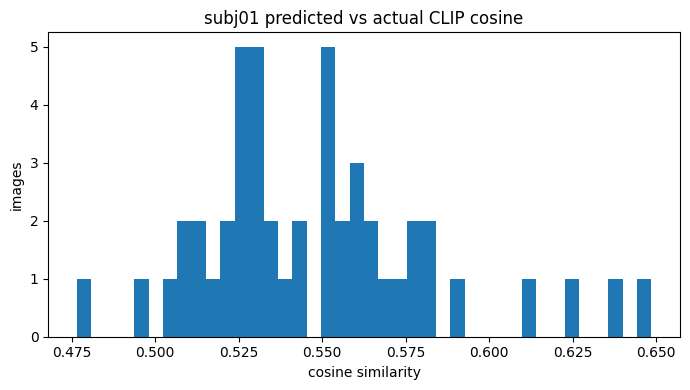

saved: /mnt/braid2-flatmap-data/outputs/production_clip_subject01_baseline_shared1000_image_id_holdout_baseline_subj01_20260907_013858/clip_embedding_eval_hists/subj01_clip_cos_flat_hist.png
  subject   N  clip_mse  clip_cos_flat_mean  clip_cos_flat_median  \
0  subj01  48  0.869404            0.548251              0.542199   

   clip_cos_token_mean  clip_cos_token_median                 split_policy  \
0             0.545083               0.538583  shared1000_image_id_holdout   

                   target_source  
0  cached_actual_clip_embeddings  
saved summary: /mnt/braid2-flatmap-data/outputs/production_clip_subject01_baseline_shared1000_image_id_holdout_baseline_subj01_20260907_013858/shared1000_clip_embedding_eval_summary.csv


In [20]:
def final_eval_indices_for_subject(subject, n_available):
    n_requested = min(FINAL_EVAL_IMAGES_PER_SUBJECT, n_available)
    if n_requested >= n_available:
        return list(range(n_available))
    seed = SEED + SUBJECT_TO_IDX[subject]
    rng = np.random.RandomState(seed)
    return sorted(rng.choice(n_available, size=n_requested, replace=False).astype(int).tolist())


CLIP_EVAL_ROWS = []
CLIP_EVAL_HIST_DIR = f"{OUTPUT_DIR}/clip_embedding_eval_hists"
os.makedirs(CLIP_EVAL_HIST_DIR, exist_ok=True)

for subject in FINAL_EVAL_SUBJECTS:
    pred = load_subject_clip_prediction(subject)
    ids = [int(i) for i in pred["shared_img_ids"]]
    pred_clip_tokens = pred["pred_clip_tokens"].float()
    true_clip_tokens = clip_targets_for_ids(subject, ids).float()
    n = min(FINAL_EVAL_IMAGES_PER_SUBJECT, len(ids), pred_clip_tokens.shape[0], true_clip_tokens.shape[0])
    if n < 1:
        raise RuntimeError(f"no CLIP eval rows available for {subject}")

    eval_indices = final_eval_indices_for_subject(subject, n_available=min(len(ids), pred_clip_tokens.shape[0], true_clip_tokens.shape[0]))
    pred_eval = pred_clip_tokens[eval_indices].float().contiguous()
    true_eval = true_clip_tokens[eval_indices].float().contiguous()
    eval_ids = [ids[i] for i in eval_indices]

    flat_pred = pred_eval.flatten(1)
    flat_true = true_eval.flatten(1)
    image_cos = F.cosine_similarity(flat_pred, flat_true, dim=1).cpu().numpy()
    token_cos = F.cosine_similarity(pred_eval, true_eval, dim=-1).mean(dim=1).cpu().numpy()
    image_mse = ((pred_eval - true_eval) ** 2).flatten(1).mean(dim=1).cpu().numpy()

    row = {
        "subject": subject,
        "N": int(len(eval_indices)),
        "clip_mse": float(np.mean(image_mse)),
        "clip_cos_flat_mean": float(np.mean(image_cos)),
        "clip_cos_flat_median": float(np.median(image_cos)),
        "clip_cos_token_mean": float(np.mean(token_cos)),
        "clip_cos_token_median": float(np.median(token_cos)),
        "split_policy": SPLIT_POLICY,
        "target_source": "cached_actual_clip_embeddings",
    }
    CLIP_EVAL_ROWS.append(row)
    print(pd.DataFrame([row]))

    per_image_path = f"{OUTPUT_DIR}/{subject}_shared1000_clip_embedding_eval.csv"
    pd.DataFrame({
        "subject": subject,
        "img_id": eval_ids,
        "clip_mse": image_mse,
        "clip_cos_flat": image_cos,
        "clip_cos_token_mean": token_cos,
    }).to_csv(per_image_path, index=False)
    print("saved:", per_image_path)

    hist_path = f"{CLIP_EVAL_HIST_DIR}/{subject}_clip_cos_flat_hist.png"
    plt.figure(figsize=(7, 4))
    plt.hist(image_cos, bins=40)
    plt.title(f"{subject} predicted vs actual CLIP cosine")
    plt.xlabel("cosine similarity")
    plt.ylabel("images")
    plt.tight_layout()
    plt.savefig(hist_path, dpi=160)
    plt.show()
    print("saved:", hist_path)

clip_eval_summary = pd.DataFrame(CLIP_EVAL_ROWS)
CLIP_EVAL_SUMMARY_PATH = f"{OUTPUT_DIR}/shared1000_clip_embedding_eval_summary.csv"
clip_eval_summary.to_csv(CLIP_EVAL_SUMMARY_PATH, index=False)
print(clip_eval_summary)
print("saved summary:", CLIP_EVAL_SUMMARY_PATH)
